In [18]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
import numpy as np

from transformers import AdamW, get_cosine_schedule_with_warmup
from transformers import ViTForImageClassification, ViTConfig
from transformers import AutoImageProcessor, DefaultDataCollator
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch import nn

Tiny ImageNet contains 100000 images of 200 classes (500 for each class) downsized to 64×64 colored images. Each class has 500 training images, 50 validation images and 50 test images.

Let's download and train; the images are quite small 

In [2]:
# Load the Tiny ImageNet dataset
dataset = load_dataset("zh-plus/tiny-imagenet")

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

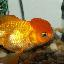

In [4]:
# View an image 
dataset['train']['image'][123]

In [ ]:

# 2. Define image transformations
# We'll use a pre-trained image processor to get the expected image size and normalization
# For ViT, a common pre-trained model is 'google/vit-base-patch16-224'
image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224", use_fast=True)

normalize = transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_processor.size["height"]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize,
])

def preprocess_images(examples):
    # Apply transformations to each image
    examples["pixel_values"] = [_transforms(image.convert("RGB")) for image in examples["image"]]
    return examples

# Apply transformations to the 'train' split
processed_train_dataset = dataset["train"].map(preprocess_images, batched=True, remove_columns=["image"])
processed_valid_dataset = dataset["valid"].map(preprocess_images, batched=True, remove_columns=["image"])

# 3. Create a data collator
data_collator = DefaultDataCollator(return_tensors="pt")

train_dataloader = DataLoader(
    processed_train_dataset,
    shuffle=True,
    batch_size=128, # You can adjust this batch size
    collate_fn=data_collator,
    num_workers=4 # Adjust based on your system's capabilities
)

valid_dataloader = DataLoader(
    processed_valid_dataset,
    shuffle=True,
    batch_size=128, # You can adjust this batch size
    collate_fn=data_collator,
    num_workers=4 # Adjust based on your system's capabilities
)

In [23]:
next(iter(train_dataloader))['pixel_values'].shape

torch.Size([128, 3, 224, 224])

# Train using own loop 

We load in the pretrained configuration, change it for TinyImagenet and train. 

In [27]:
config = ViTConfig.from_pretrained("google/vit-base-patch16-224")
config.num_labels = 200
model = ViTForImageClassification(config)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [28]:
# Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Define the number of total training steps and warmup steps
num_epochs = 30  # Adjust as needed
total_steps = len(train_dataloader) * num_epochs  # Total number of training steps
# warmup_steps = int(0.1 * total_steps)  # 10% of total steps for warmup
warmup_steps = 200

# Create the learning rate scheduler
scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)


In [30]:
# Training and validation function
def train_and_validate(model, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
            inputs = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(pixel_values=inputs)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()
        
            # Step the scheduler
            scheduler.step()


            train_loss += loss.item()
            _, predicted = torch.max(outputs.logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(correct / total)

        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):
                inputs = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(pixel_values=inputs)
                loss = criterion(outputs.logits, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.logits, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total)

        # Print metrics
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}")
        print(f"Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Training and validation
epochs = 10  # Set the number of epochs
train_losses, val_losses, train_accuracies, val_accuracies = train_and_validate(model, train_dataloader, valid_dataloader, epochs)

Validation Epoch 1: 100%|████| 79/79 [04:18<00:00,  3.27s/it]


Epoch 1/10
Train Loss: 3.2057, Train Accuracy: 0.2727
Val Loss: 3.6147, Val Accuracy: 0.2149


Validation Epoch 2: 100%|████| 79/79 [04:38<00:00,  3.53s/it]


Epoch 2/10
Train Loss: 2.9285, Train Accuracy: 0.3204
Val Loss: 3.5951, Val Accuracy: 0.2235


Validation Epoch 3: 100%|████| 79/79 [04:31<00:00,  3.43s/it]


...

Epoch 8/10
Train Loss: 0.0804, Train Accuracy: 0.9896
Val Loss: 4.6388, Val Accuracy: 0.2066


Validation Epoch 9: 100%|████| 79/79 [04:47<00:00,  3.64s/it]


Epoch 9/10
Train Loss: 0.0469, Train Accuracy: 0.9927
Val Loss: 4.7828, Val Accuracy: 0.2059


Validation Epoch 10: 100%|███| 79/79 [04:26<00:00,  3.38s/it]

Epoch 10/10
Train Loss: 0.0406, Train Accuracy: 0.9933
Val Loss: 4.9487, Val Accuracy: 0.1970


In [34]:
temp_batch = next(iter(train_dataloader))

In [39]:
output  = model(temp_batch['pixel_values'].to('cuda'))

In [42]:
torch.argmax(output.logits, axis=1)

tensor([  4, 146, 149, 124, 116, 121, 112, 183, 166,  51,  78, 186, 111,  53,
         14,  20,  75,  31, 118,  47, 125, 188, 134,  29, 167, 171, 103, 107,
        137, 195, 183,  32,  34, 160,  73, 188,  48, 186,   0,  22, 146, 186,
        120,  62, 113,  90, 121,  41,  23,  84, 196,   0, 162,  25, 111,  27,
        197,  18, 143,   4, 164,  26, 165, 189, 131, 199,  91,  35,  43,  32,
        140,   9,  28, 181, 103, 154,  53, 182, 151,  13, 105,   2,  13, 181,
         10, 185,  99,  47, 173,  65, 197, 187,  27, 184,  64,  75,  60,  59,
        149,  47, 125, 199, 140,  17, 110, 160,   5,  18,  96,  97,  62,   4,
         48,  87,  17,  55,  63, 132, 134,  59,  59, 174, 146, 176, 199,  85,
        194, 192], device='cuda:0')

In [46]:
temp_batch['labels']

tensor([  4, 146, 149, 124, 116, 121, 112, 183, 166,  51,  78, 186, 111,  53,
         14,  20,  75,  31, 118,  47, 125, 188, 134,  29, 167, 171, 103, 107,
        137, 195, 183,  32,  34, 160,  73, 188,  48, 186,   0,  22, 146, 186,
        120,  62, 113,  90, 121,  41,  23,  84, 196,   0, 162,  25, 111,  27,
        197,  18, 143,   4, 164,  26, 165, 189, 131, 199,  91,  35,  43,  32,
        140,   9,  28, 181, 103, 154,  53, 182, 151,  13, 105,   2,  13, 181,
         10, 185,  99,  47, 173,  65, 197, 187,  27, 184,  64,  75,  60,  59,
        149,  47, 125, 199, 140,  17, 110, 160,   5,  18,  96,  97,  62,   4,
         48,  87,  17,  55,  63, 132, 134,  59,  59, 174, 146, 176, 199,  85,
        194, 192])

In [31]:
torch.save(model, 'model.pth')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
